<a href="https://colab.research.google.com/github/vidhan66/Book-Recommendation-System/blob/main/Book_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
books = '/content/Books.csv'
ratings = '/content/Ratings.csv'
users = '/content/Users.csv'

In [2]:
import pandas as pd
users_df = pd.read_csv(users)
ratings_df = pd.read_csv(ratings)
books_df = pd.read_csv(books)

<ipython-input-2-746080277>:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books_df = pd.read_csv(books)


In [3]:
users_df.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [4]:
books_df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [5]:
ratings_df.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [6]:
print(users_df.shape,ratings_df.shape,books_df.shape)

(278858, 3) (1149780, 3) (271360, 8)


# ***Data Analysis with EDA***

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


In [9]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [10]:
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


In [11]:
users_df.duplicated().sum()

np.int64(0)

In [12]:
books_df.duplicated().sum()

np.int64(0)

In [13]:
ratings_df.duplicated().sum()

np.int64(0)

In [14]:
users_df.isnull().sum()

,0
User-ID,0
Location,0
Age,110762


In [15]:
ratings_df.isnull().sum()

,0
User-ID,0
ISBN,0
Book-Rating,0


In [16]:
books_df.isnull().sum()

,0
ISBN,0
Book-Title,0
Book-Author,2
Year-Of-Publication,0
Publisher,2
Image-URL-S,0
Image-URL-M,0
Image-URL-L,3


In [17]:
books_df.describe()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
count,271360,271360,271358,271360,271358,271360,271360,271357
unique,271360,242135,102022,202,16807,271044,271044,271041
top,3462017942,Selected Poems,Agatha Christie,2002,Harlequin,http://images.amazon.com/images/P/042509474X.0...,http://images.amazon.com/images/P/042509474X.0...,http://images.amazon.com/images/P/006091985X.0...
freq,1,27,632,13903,7535,2,2,2


In [18]:
books_df[books_df['Year-Of-Publication']==2050]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
80264,0140301690,Alice's Adventures in Wonderland and Through t...,Lewis Carroll,2050,Puffin Books,http://images.amazon.com/images/P/0140301690.0...,http://images.amazon.com/images/P/0140301690.0...,http://images.amazon.com/images/P/0140301690.0...
97826,0140201092,Outline of European Architecture (Pelican S.),Nikolaus Pevsner,2050,Penguin USA,http://images.amazon.com/images/P/0140201092.0...,http://images.amazon.com/images/P/0140201092.0...,http://images.amazon.com/images/P/0140201092.0...


<Axes: xlabel='Year-Of-Publication', ylabel='count'>

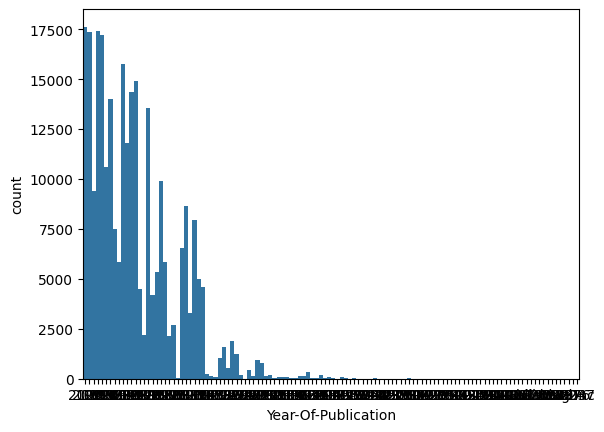

In [19]:
sns.countplot(x=books_df['Year-Of-Publication'],width=1)

<ipython-input-20-1147092211>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(users_df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

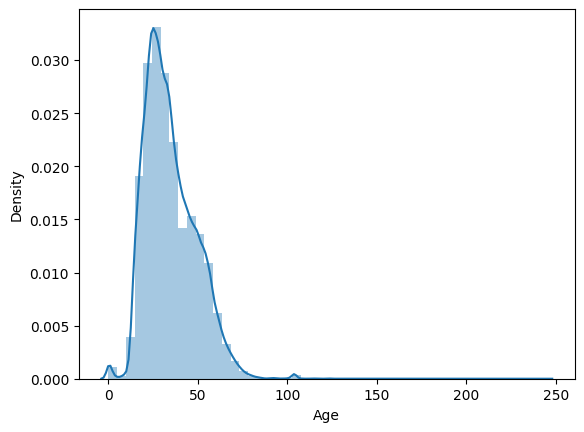

In [20]:
sns.distplot(users_df['Age'])

# ***Model Building***

In [21]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

### ***Popularity Based***

In [22]:
new_df=ratings_df.merge(books_df,on='ISBN')

In [23]:
num_ratings =new_df.groupby('Book-Title')['User-ID'].count().rename('num_ratings').reset_index()
num_ratings

,Book-Title,num_ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241066,Ã?Â?lpiraten.,2
241067,Ã?Â?rger mit Produkt X. Roman.,4
241068,Ã?Â?sterlich leben.,1
241069,Ã?Â?stlich der Berge.,3


In [24]:
avg_ratings = new_df.groupby('Book-Title')['Book-Rating'].mean()
avg_ratings = avg_ratings.rename('avg_ratings').reset_index()
avg_ratings

,Book-Title,avg_ratings
0,A Light in the Storm: The Civil War Diary of ...,2.250000
1,Always Have Popsicles,0.000000
2,Apple Magic (The Collector's series),0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,0.000000
...,...,...
241066,Ã?Â?lpiraten.,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,5.250000
241068,Ã?Â?sterlich leben.,7.000000
241069,Ã?Â?stlich der Berge.,2.666667


In [25]:
popular = num_ratings.merge(avg_ratings,on='Book-Title')
popular = popular[popular['num_ratings']>200].sort_values('avg_ratings',ascending=False).head(50)
popular=popular.merge(books_df,on='Book-Title').drop_duplicates('Book-Title')[['Book-Title','num_ratings','avg_ratings','Book-Author','Year-Of-Publication','Image-URL-S']]
popular

,Book-Title,num_ratings,avg_ratings,Book-Author,Year-Of-Publication,Image-URL-S
0,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804,J. K. Rowling,1999,http://images.amazon.com/images/P/0439136350.0...
3,Harry Potter and the Goblet of Fire (Book 4),387,5.824289,J. K. Rowling,2000,http://images.amazon.com/images/P/0439139597.0...
5,Harry Potter and the Sorcerer's Stone (Book 1),278,5.737410,J. K. Rowling,1998,http://images.amazon.com/images/P/0590353403.0...
9,Harry Potter and the Order of the Phoenix (Boo...,347,5.501441,J. K. Rowling,2003,http://images.amazon.com/images/P/043935806X.0...
13,Ender's Game (Ender Wiggins Saga (Paperback)),249,5.409639,Orson Scott Card,1992,http://images.amazon.com/images/P/0312853238.0...
17,Harry Potter and the Chamber of Secrets (Book 2),556,5.183453,J. K. Rowling,2000,http://images.amazon.com/images/P/0439064872.0...
20,The Hobbit : The Enchanting Prelude to The Lor...,281,5.007117,J.R.R. TOLKIEN,1986,http://images.amazon.com/images/P/0345339681.0...
21,The Fellowship of the Ring (The Lord of the Ri...,368,4.948370,J.R.R. TOLKIEN,1986,http://images.amazon.com/images/P/0345339703.0...
30,Harry Potter and the Sorcerer's Stone (Harry P...,575,4.895652,J. K. Rowling,1999,http://images.amazon.com/images/P/059035342X.0...
32,"The Two Towers (The Lord of the Rings, Part 2)",260,4.880769,J.R.R. TOLKIEN,1986,http://images.amazon.com/images/P/0345339711.0...


### ***Content Based Filtering***

In [26]:
cleaned_df = new_df.dropna(subset=['Book-Author'])
cleaned_df

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...
...,...,...,...,...,...,...,...,...,...,...
1031131,276704,0876044011,0,Edgar Cayce on the Akashic Records: The Book o...,Kevin J. Todeschi,1998,A.R.E. Press (Association of Research &amp; Enlig,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...
1031132,276704,1563526298,9,Get Clark Smart : The Ultimate Guide for the S...,Clark Howard,2000,Longstreet Press,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...
1031133,276706,0679447156,0,Eight Weeks to Optimum Health: A Proven Progra...,Andrew Weil,1997,Alfred A. Knopf,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...
1031134,276709,0515107662,10,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,1996,Jove Books,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...


In [27]:
CBF_data = cleaned_df.merge(num_ratings,on='Book-Title')
CBF_data = CBF_data.merge(avg_ratings,on='Book-Title')[['User-ID','Book-Title','Book-Author','Book-Rating','num_ratings','avg_ratings','Image-URL-S']]
CBF_data = CBF_data.sort_values('User-ID')
CBF_data

,User-ID,Book-Title,Book-Author,Book-Rating,num_ratings,avg_ratings,Image-URL-S
8429,2,Classical Mythology,Mark P. O. Morford,0,2,3.500000,http://images.amazon.com/images/P/0195153448.0...
8430,8,Clara Callan,Richard Bruce Wright,5,14,4.928571,http://images.amazon.com/images/P/0002005018.0...
8432,8,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,0,11,4.272727,http://images.amazon.com/images/P/0374157065.0...
8431,8,Decision in Normandy,Carlo D'Este,0,3,5.000000,http://images.amazon.com/images/P/0060973129.0...
8434,8,The Kitchen God's Wife,Amy Tan,0,311,2.996785,http://images.amazon.com/images/P/0399135782.0...
...,...,...,...,...,...,...,...
8425,278854,The Cat Who Ate Danish Modern (Cat Who... (Pap...,Lilian Jackson Braun,0,81,2.209877,http://images.amazon.com/images/P/0515087122.0...
8423,278854,Hornet's Nest,Patricia Daniels Cornwell,7,248,2.471774,http://images.amazon.com/images/P/042516098X.0...
8421,278854,Final Harvest : Poems,Emily Dickinson,7,11,1.363636,http://images.amazon.com/images/P/0316184152.0...
8428,278854,Ashes to Ashes,TAMI HOAG,8,220,2.250000,http://images.amazon.com/images/P/0553579606.0...


In [28]:
active_users = CBF_data.groupby('User-ID')['Book-Rating'].count()
active_users = active_users[active_users>=100]
CBF_data = CBF_data[CBF_data['User-ID'].isin(active_users.index)]
good_books = CBF_data.groupby('Book-Title')['Book-Rating'].count()
good_books = good_books[good_books>=150]
CBF_data = CBF_data[CBF_data['Book-Title'].isin(good_books.index)]
CBF_data

,User-ID,Book-Title,Book-Author,Book-Rating,num_ratings,avg_ratings,Image-URL-S
9002,254,The Kitchen God's Wife,Amy Tan,0,311,2.996785,http://images.amazon.com/images/P/080410753X.0...
9001,254,The Joy Luck Club,Amy Tan,0,555,3.055856,http://images.amazon.com/images/P/0804106304.0...
8988,254,Snow Falling on Cedars,David Guterson,0,662,3.252266,http://images.amazon.com/images/P/067976402X.0...
8940,254,Girl with a Pearl Earring,Tracy Chevalier,0,526,4.218631,http://images.amazon.com/images/P/0452282152.0...
8802,254,The Cider House Rules,John Irving,0,393,2.969466,http://images.amazon.com/images/P/0345387651.0...
...,...,...,...,...,...,...,...
5695,278418,A Time to Kill,JOHN GRISHAM,0,549,3.122040,http://images.amazon.com/images/P/0440211727.0...
5717,278418,The Street Lawyer,JOHN GRISHAM,0,545,2.851376,http://images.amazon.com/images/P/0440225701.0...
5685,278418,Red Dragon,Thomas Harris,0,402,3.606965,http://images.amazon.com/images/P/0440206154.0...
5722,278418,Tara Road,Maeve Binchy,0,304,3.036184,http://images.amazon.com/images/P/0440235596.0...


In [29]:
CBF_data['Title-Author'] = CBF_data['Book-Title'] + " by " + CBF_data['Book-Author']
CBF_data

<ipython-input-29-2864637524>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CBF_data['Title-Author'] = CBF_data['Book-Title'] + " by " + CBF_data['Book-Author']


,User-ID,Book-Title,Book-Author,Book-Rating,num_ratings,avg_ratings,Image-URL-S,Title-Author
9002,254,The Kitchen God's Wife,Amy Tan,0,311,2.996785,http://images.amazon.com/images/P/080410753X.0...,The Kitchen God's Wife by Amy Tan
9001,254,The Joy Luck Club,Amy Tan,0,555,3.055856,http://images.amazon.com/images/P/0804106304.0...,The Joy Luck Club by Amy Tan
8988,254,Snow Falling on Cedars,David Guterson,0,662,3.252266,http://images.amazon.com/images/P/067976402X.0...,Snow Falling on Cedars by David Guterson
8940,254,Girl with a Pearl Earring,Tracy Chevalier,0,526,4.218631,http://images.amazon.com/images/P/0452282152.0...,Girl with a Pearl Earring by Tracy Chevalier
8802,254,The Cider House Rules,John Irving,0,393,2.969466,http://images.amazon.com/images/P/0345387651.0...,The Cider House Rules by John Irving
...,...,...,...,...,...,...,...,...
5695,278418,A Time to Kill,JOHN GRISHAM,0,549,3.122040,http://images.amazon.com/images/P/0440211727.0...,A Time to Kill by JOHN GRISHAM
5717,278418,The Street Lawyer,JOHN GRISHAM,0,545,2.851376,http://images.amazon.com/images/P/0440225701.0...,The Street Lawyer by JOHN GRISHAM
5685,278418,Red Dragon,Thomas Harris,0,402,3.606965,http://images.amazon.com/images/P/0440206154.0...,Red Dragon by Thomas Harris
5722,278418,Tara Road,Maeve Binchy,0,304,3.036184,http://images.amazon.com/images/P/0440235596.0...,Tara Road by Maeve Binchy


In [30]:
user_preferences = CBF_data.groupby('User-ID')['Title-Author'].apply(list)
user_preferences

,Title-Author
User-ID,
254,"[The Kitchen God's Wife by Amy Tan, The Joy Lu..."
507,"[1st to Die: A Novel by James Patterson, The G..."
882,"[The Alienist by Caleb Carr, The Reader by Ber..."
1424,[The Poisonwood Bible: A Novel by Barbara King...
1435,"[The Bean Trees by Barbara Kingsolver, Where t..."
...,...
277478,"[Wild Animus by Rich Shapero, She's Come Undon..."
277639,"[Presumed Innocent by Scott Turow, The Client ..."
278137,"[Message in a Bottle by Nicholas Sparks, Tara ..."


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [32]:
all_titles = CBF_data['Title-Author'].unique()
title_vectorizer = TfidfVectorizer()
title_vectors = title_vectorizer.fit_transform(all_titles)
similarity = cosine_similarity(title_vectors)
similarity

array([[1.        , 0.35692765, 0.00763831, ..., 0.00763831, 0.01188   ,
        0.05012777],
       [0.35692765, 1.        , 0.00788289, ..., 0.00788289, 0.0122604 ,
        0.05173286],
       [0.00763831, 0.00788289, 1.        , ..., 0.78735284, 0.01144458,
        0.13924665],
       ...,
       [0.00763831, 0.00788289, 0.78735284, ..., 1.        , 0.01144458,
        0.13924665],
       [0.01188   , 0.0122604 , 0.01144458, ..., 0.01144458, 1.        ,
        0.0112249 ],
       [0.05012777, 0.05173286, 0.13924665, ..., 0.13924665, 0.0112249 ,
        1.        ]])

In [33]:
book_indices = {title : index for index, title in enumerate(all_titles)}

In [34]:
user_recommendations ={}
for user,books in user_preferences.items():
    recommended_books = set()
    book_score={}

    for book in books:
        if book not in book_indices:
          continue

        book_index = book_indices[book]
        similar_books = similarity[book_index].argsort()[::-1]
        for index in similar_books:
            similar_book = all_titles[index]
            similarity_score = similarity[book_index][index]

            if similar_book not in books:
                recommended_books.add(similar_book)
                book_score[similar_book] = similarity_score

            if len(recommended_books) >= 5:
                break
        if len(recommended_books) >= 5:
            break
    user_recommendations[user] = list(recommended_books),book_score

In [35]:
recommendations_list = []
for user, (books,scores) in user_recommendations.items():
    for book in books:
        recommendations_list.append({'User-ID': user, 'Title-Author': book,'CBF_Score':scores[book]})

recommendations_df = pd.DataFrame(recommendations_list)
recommendations_df

,User-ID,Title-Author,CBF_Score
0,254,The Catcher in the Rye by J. D. Salinger,0.061427
1,254,The Rainmaker by John Grisham,0.051276
2,254,The Brethren by JOHN GRISHAM,0.051276
3,254,The Pilot's Wife : A Novel by Anita Shreve,0.227809
4,254,The Hundred Secret Senses by Amy Tan,0.345853
...,...,...,...
7875,278418,The Firm by JOHN GRISHAM,0.015048
7876,278418,The Rainmaker by John Grisham,0.015048
7877,278418,The Brethren by JOHN GRISHAM,0.015048
7878,278418,The King of Torts by John Grisham,0.227977


In [36]:
CBF_data = CBF_data.drop_duplicates(subset='Title-Author')
CBF_data

,User-ID,Book-Title,Book-Author,Book-Rating,num_ratings,avg_ratings,Image-URL-S,Title-Author
9002,254,The Kitchen God's Wife,Amy Tan,0,311,2.996785,http://images.amazon.com/images/P/080410753X.0...,The Kitchen God's Wife by Amy Tan
9001,254,The Joy Luck Club,Amy Tan,0,555,3.055856,http://images.amazon.com/images/P/0804106304.0...,The Joy Luck Club by Amy Tan
8988,254,Snow Falling on Cedars,David Guterson,0,662,3.252266,http://images.amazon.com/images/P/067976402X.0...,Snow Falling on Cedars by David Guterson
8940,254,Girl with a Pearl Earring,Tracy Chevalier,0,526,4.218631,http://images.amazon.com/images/P/0452282152.0...,Girl with a Pearl Earring by Tracy Chevalier
8802,254,The Cider House Rules,John Irving,0,393,2.969466,http://images.amazon.com/images/P/0345387651.0...,The Cider House Rules by John Irving
...,...,...,...,...,...,...,...,...
538460,145369,The Firm,JOHN GRISHAM,0,569,3.080844,http://images.amazon.com/images/P/0385319053.0...,The Firm by JOHN GRISHAM
643237,174092,Snow Falling on Cedars,David Gutterson,0,662,3.252266,http://images.amazon.com/images/P/037570437X.0...,Snow Falling on Cedars by David Gutterson
667513,180651,Snow Falling on Cedars,David G. Uterson,8,662,3.252266,http://images.amazon.com/images/P/0747522251.0...,Snow Falling on Cedars by David G. Uterson
915211,244685,Lightning,Patricia Potter,9,274,2.627737,http://images.amazon.com/images/P/0553290703.0...,Lightning by Patricia Potter


In [37]:
recommendations_df = recommendations_df.merge(CBF_data,on='Title-Author')
recommendations_df = recommendations_df.rename(columns={'User-ID_x':'User-ID'})
recommendations_df = recommendations_df.drop(columns=['User-ID_y'])
recommendations_df

,User-ID,Title-Author,CBF_Score,Book-Title,Book-Author,Book-Rating,num_ratings,avg_ratings,Image-URL-S
0,254,The Catcher in the Rye by J. D. Salinger,0.061427,The Catcher in the Rye,J. D. Salinger,0,449,4.545657,http://images.amazon.com/images/P/0553149660.0...
1,254,The Rainmaker by John Grisham,0.051276,The Rainmaker,John Grisham,8,501,2.922156,http://images.amazon.com/images/P/0385424736.0...
2,254,The Brethren by JOHN GRISHAM,0.051276,The Brethren,JOHN GRISHAM,0,556,2.850719,http://images.amazon.com/images/P/0385497466.0...
3,254,The Pilot's Wife : A Novel by Anita Shreve,0.227809,The Pilot's Wife : A Novel,Anita Shreve,0,568,3.593310,http://images.amazon.com/images/P/0316601950.0...
4,254,The Hundred Secret Senses by Amy Tan,0.345853,The Hundred Secret Senses,Amy Tan,0,336,2.830357,http://images.amazon.com/images/P/080411109X.0...
...,...,...,...,...,...,...,...,...,...
7875,278418,The Firm by JOHN GRISHAM,0.015048,The Firm,JOHN GRISHAM,0,569,3.080844,http://images.amazon.com/images/P/0385319053.0...
7876,278418,The Rainmaker by John Grisham,0.015048,The Rainmaker,John Grisham,8,501,2.922156,http://images.amazon.com/images/P/0385424736.0...
7877,278418,The Brethren by JOHN GRISHAM,0.015048,The Brethren,JOHN GRISHAM,0,556,2.850719,http://images.amazon.com/images/P/0385497466.0...
7878,278418,The King of Torts by John Grisham,0.227977,The King of Torts,John Grisham,0,458,3.039301,http://images.amazon.com/images/P/0385508042.0...


In [38]:
recommendations_cbf = recommendations_df.groupby('User-ID').agg({
    'Book-Title': list,
    'Book-Author': list,
    'Book-Rating': list,
    'num_ratings': list,
    'avg_ratings': list,
    'Image-URL-S': list,
    'Title-Author': list,
    'CBF_Score': list
}).reset_index()
recommendations_cbf

,User-ID,Book-Title,Book-Author,Book-Rating,num_ratings,avg_ratings,Image-URL-S,Title-Author,CBF_Score
0,254,"[The Catcher in the Rye, The Rainmaker, The Br...","[J. D. Salinger, John Grisham, JOHN GRISHAM, A...","[0, 8, 0, 0, 0]","[449, 501, 556, 568, 336]","[4.5456570155902005, 2.9221556886227544, 2.850...",[http://images.amazon.com/images/P/0553149660....,"[The Catcher in the Rye by J. D. Salinger, The...","[0.061427105540847314, 0.0512763239755083, 0.0..."
1,507,"[The Beach House, 2nd Chance, Violets Are Blue...","[James Patterson, James Patterson, James Patte...","[0, 10, 0, 0, 0]","[435, 356, 379, 396, 457]","[3.3471264367816094, 3.269662921348315, 2.9551...",[http://images.amazon.com/images/P/0446612545....,"[The Beach House by James Patterson, 2nd Chanc...","[0.33436477858324, 0.30868604261456056, 0.2839..."
2,882,"[The Firm, The Catcher in the Rye, The Rainmak...","[JOHN GRISHAM, J. D. Salinger, John Grisham, J...","[0, 0, 8, 0, 0]","[569, 449, 501, 449, 617]","[3.0808435852372584, 4.5456570155902005, 2.922...",[http://images.amazon.com/images/P/0385319053....,"[The Firm by JOHN GRISHAM, The Catcher in the ...","[0.0605180827689603, 0.0724983846180991, 0.060..."
3,1424,"[1st to Die: A Novel, The Lovely Bones: A Nove...","[James Patterson, Alice Sebold, Chris Bohjalia...","[0, 0, 0, 0, 0]","[509, 1295, 380, 568, 828]","[3.5756385068762278, 4.468725868725869, 3.1131...",[http://images.amazon.com/images/P/0316666009....,"[1st to Die: A Novel by James Patterson, The L...","[0.11887173389054166, 0.13681588455997523, 0.1..."
4,1435,"[The Firm, The Catcher in the Rye, The Rainmak...","[JOHN GRISHAM, J. D. Salinger, John Grisham, B...","[0, 0, 8, 0, 0]","[569, 449, 501, 494, 449]","[3.0808435852372584, 4.5456570155902005, 2.922...",[http://images.amazon.com/images/P/0385319053....,"[The Firm by JOHN GRISHAM, The Catcher in the ...","[0.05464484659415686, 0.06546246881125822, 0.0..."
...,...,...,...,...,...,...,...,...,...
1571,277478,"[The Firm, The Rainmaker, The Brethren, The Br...","[JOHN GRISHAM, John Grisham, John Grisham, JOH...","[0, 8, 0, 0, 0]","[569, 501, 556, 556, 509]","[3.0808435852372584, 2.9221556886227544, 2.850...",[http://images.amazon.com/images/P/0385319053....,"[The Firm by JOHN GRISHAM, The Rainmaker by Jo...","[0.013867897994840978, 0.013867897994840978, 0..."
1572,277639,"[The Firm, The Rainmaker, The Brethren, Presum...","[JOHN GRISHAM, John Grisham, JOHN GRISHAM, Dal...","[0, 8, 0, 0, 0]","[569, 501, 556, 294, 617]","[3.0808435852372584, 2.9221556886227544, 2.850...",[http://images.amazon.com/images/P/0385319053....,"[The Firm by JOHN GRISHAM, The Rainmaker by Jo...","[0.014395500743662205, 0.014395500743662205, 0..."
1573,278137,"[The Catcher in the Rye, A Bend in the Road, A...","[J. D. Salinger, Nicholas Sparks, Nicholas Spa...","[0, 0, 0, 0, 0]","[449, 346, 378, 449, 650]","[4.5456570155902005, 3.3641618497109826, 3.399...",[http://images.amazon.com/images/P/0553149660....,"[The Catcher in the Rye by J. D. Salinger, A B...","[0.16508853599365186, 0.48503892273882765, 0.3..."
1574,278188,"[A Time to Kill, A Time to Kill, The Horse Whi...","[JOHN GRISHAM, John Grisham, Nicholas Evans, N...","[0, 10, 0, 0, 0]","[549, 549, 507, 496, 650]","[3.122040072859745, 3.122040072859745, 2.68639...",[http://images.amazon.com/images/P/0440211727....,"[A Time to Kill by JOHN GRISHAM, A Time to Kil...","[0.17948318324249618, 0.17948318324249618, 0.1..."


## ***Collaborative Based***

In [39]:
CF_data = cleaned_df.merge(num_ratings,on='Book-Title')
CF_data = CF_data.merge(avg_ratings,on='Book-Title')[['User-ID','Book-Title','Book-Author','Book-Rating','num_ratings','avg_ratings','Image-URL-S']]
CF_data = CF_data.sort_values('User-ID')
CF_data

,User-ID,Book-Title,Book-Author,Book-Rating,num_ratings,avg_ratings,Image-URL-S
8429,2,Classical Mythology,Mark P. O. Morford,0,2,3.500000,http://images.amazon.com/images/P/0195153448.0...
8430,8,Clara Callan,Richard Bruce Wright,5,14,4.928571,http://images.amazon.com/images/P/0002005018.0...
8432,8,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,0,11,4.272727,http://images.amazon.com/images/P/0374157065.0...
8431,8,Decision in Normandy,Carlo D'Este,0,3,5.000000,http://images.amazon.com/images/P/0060973129.0...
8434,8,The Kitchen God's Wife,Amy Tan,0,311,2.996785,http://images.amazon.com/images/P/0399135782.0...
...,...,...,...,...,...,...,...
8425,278854,The Cat Who Ate Danish Modern (Cat Who... (Pap...,Lilian Jackson Braun,0,81,2.209877,http://images.amazon.com/images/P/0515087122.0...
8423,278854,Hornet's Nest,Patricia Daniels Cornwell,7,248,2.471774,http://images.amazon.com/images/P/042516098X.0...
8421,278854,Final Harvest : Poems,Emily Dickinson,7,11,1.363636,http://images.amazon.com/images/P/0316184152.0...
8428,278854,Ashes to Ashes,TAMI HOAG,8,220,2.250000,http://images.amazon.com/images/P/0553579606.0...


In [40]:
exp_users = CF_data.groupby('User-ID')['Book-Rating'].count()
exp_users = exp_users[exp_users>=300]
active_user = CF_data.groupby('User-ID')['Book-Rating'].count()
active_user = active_user[active_user>=100]
CF_data1 = CF_data[CF_data['User-ID'].isin(exp_users.index)]
CF_data2 = CF_data[CF_data['User-ID'].isin(active_user.index)]

In [41]:
CF_data1['Title-Author'] = CF_data1['Book-Title'] + " by " + CF_data1['Book-Author']
CF_data1

<ipython-input-41-3904886317>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CF_data1['Title-Author'] = CF_data1['Book-Title'] + " by " + CF_data1['Book-Author']


,User-ID,Book-Title,Book-Author,Book-Rating,num_ratings,avg_ratings,Image-URL-S,Title-Author
9022,254,7b,Stella Cameron,0,30,1.366667,http://images.amazon.com/images/P/1551667959.0...,7b by Stella Cameron
9005,254,The Beatles Anthology,Paul McCartney,0,7,5.571429,http://images.amazon.com/images/P/0811826848.0...,The Beatles Anthology by Paul McCartney
9004,254,Cat's Cradle,Kurt Vonnegut,0,98,4.632653,http://images.amazon.com/images/P/0808520695.0...,Cat's Cradle by Kurt Vonnegut
9003,254,Dead in the Water,Julie Smith,0,63,1.984127,http://images.amazon.com/images/P/0804108552.0...,Dead in the Water by Julie Smith
9002,254,The Kitchen God's Wife,Amy Tan,0,311,2.996785,http://images.amazon.com/images/P/080410753X.0...,The Kitchen God's Wife by Amy Tan
...,...,...,...,...,...,...,...,...
5099,278418,Class Act (Men: Made In America) (Men Made in ...,Kathleen Eagle,0,1,0.000000,http://images.amazon.com/images/P/0373451849.0...,Class Act (Men: Made In America) (Men Made in ...
5082,278418,"Bachelor Tax (Harlequin Historical, No. 496)",Carolyn Davidson,0,3,2.333333,http://images.amazon.com/images/P/0373290969.0...,"Bachelor Tax (Harlequin Historical, No. 496) b..."
5111,278418,Maitland Maternity: The Inheritance,Marie Ferrarella,0,5,0.000000,http://images.amazon.com/images/P/0373484534.0...,Maitland Maternity: The Inheritance by Marie F...
5135,278418,Joe'S Miracle (Harlequin Superromance No. 70544),Helen Conrad,0,3,0.000000,http://images.amazon.com/images/P/0373705441.0...,Joe'S Miracle (Harlequin Superromance No. 7054...


In [42]:
CF_data2['Title-Author'] = CF_data2['Book-Title'] + " by " + CF_data2['Book-Author']
CF_data2 = CF_data2.drop_duplicates(subset='Title-Author')
CF_data2.sample(3)

<ipython-input-42-3094249521>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CF_data2['Title-Author'] = CF_data2['Book-Title'] + " by " + CF_data2['Book-Author']


,User-ID,Book-Title,Book-Author,Book-Rating,num_ratings,avg_ratings,Image-URL-S,Title-Author
394410,105517,The Twelfth Garfield Fat Cat 3-Pack (Garfield ...,Jim Davis,6,1,6.0,http://images.amazon.com/images/P/0345445813.0...,The Twelfth Garfield Fat Cat 3-Pack (Garfield ...
853721,230522,Tim Catchamouse (Puddle Lane Reading Program/S...,Sheila McCullagh,0,1,0.0,http://images.amazon.com/images/P/0721409091.0...,Tim Catchamouse (Puddle Lane Reading Program/S...
100700,26535,Confession,Lori Herter,0,21,2.0,http://images.amazon.com/images/P/0425133583.0...,Confession by Lori Herter


In [43]:
recommendable_books = CF_data1.groupby('Book-Title')['Book-Rating'].count()
recommendable_books = recommendable_books[recommendable_books>=80]
recommendable_books

,Book-Rating
Book-Title,
1st to Die: A Novel,131
2nd Chance,98
A Bend in the Road,90
A Is for Alibi (Kinsey Millhone Mysteries (Paperback)),105
A Map of the World,83
...,...
Whispers,96
White Oleander : A Novel,81
Wicked: The Life and Times of the Wicked Witch of the West,88


In [44]:
CF_data1 = CF_data1[CF_data1['Book-Title'].isin(recommendable_books.index)]
CF_data1 = CF_data1.drop_duplicates(subset='Title-Author')
CF_data1 = CF_data1.reset_index(drop=True)
CF_data1

,User-ID,Book-Title,Book-Author,Book-Rating,num_ratings,avg_ratings,Image-URL-S,Title-Author
0,254,The Kitchen God's Wife,Amy Tan,0,311,2.996785,http://images.amazon.com/images/P/080410753X.0...,The Kitchen God's Wife by Amy Tan
1,254,The Joy Luck Club,Amy Tan,0,555,3.055856,http://images.amazon.com/images/P/0804106304.0...,The Joy Luck Club by Amy Tan
2,254,Snow Falling on Cedars,David Guterson,0,662,3.252266,http://images.amazon.com/images/P/067976402X.0...,Snow Falling on Cedars by David Guterson
3,254,Girl with a Pearl Earring,Tracy Chevalier,0,526,4.218631,http://images.amazon.com/images/P/0452282152.0...,Girl with a Pearl Earring by Tracy Chevalier
4,254,The Cider House Rules,John Irving,0,393,2.969466,http://images.amazon.com/images/P/0345387651.0...,The Cider House Rules by John Irving
...,...,...,...,...,...,...,...,...
203,189835,The Gift,John Steinbeck,5,222,2.801802,http://images.amazon.com/images/P/0886825075.0...,The Gift by John Steinbeck
204,198711,A Time to Kill,John Grisham,0,549,3.122040,http://images.amazon.com/images/P/0922066728.0...,A Time to Kill by John Grisham
205,212898,The Rescue,Elizabeth Faucher,0,308,3.243506,http://images.amazon.com/images/P/0590415328.0...,The Rescue by Elizabeth Faucher
206,219546,The Reader,Carol Brown Janeway,0,466,3.012876,http://images.amazon.com/images/P/0679781307.0...,The Reader by Carol Brown Janeway


In [45]:
exp_user_matrix = CF_data1.pivot(index='User-ID', columns='Title-Author', values='Book-Rating').fillna(0)
active_user_matrix = CF_data2.pivot(index='User-ID', columns='Title-Author', values='Book-Rating').fillna(0)

exp_user_similarity = cosine_similarity(exp_user_matrix)
exp_user_similarity_df = pd.DataFrame(exp_user_similarity,
                                      index=exp_user_matrix.index,
                                      columns=exp_user_matrix.index)

book_indice = CF_data1.set_index('Title-Author').index
book_vectorizer = TfidfVectorizer()
book_vectors = book_vectorizer.fit_transform(book_indice)
similarity_cf = cosine_similarity(book_vectors)

In [46]:
def recommend(book_name, user_id):
    if book_name not in book_indice:
        return f"Book '{book_name}' not found in expert dataset."

    if user_id not in active_user_matrix.index:
        return f"User '{user_id}' not found in active user dataset."

    common_books = exp_user_matrix.columns.intersection(active_user_matrix.columns)
    target_user_vector = active_user_matrix.loc[user_id,common_books].values.reshape(1, -1)
    exp_user_matrix_aligned = exp_user_matrix[common_books]
    target_exp_similarities = cosine_similarity(target_user_vector, exp_user_matrix_aligned)[0]
    exp_user_similarity_dict = dict(zip(exp_user_matrix.index, target_exp_similarities))
    similar_exp_users = sorted(exp_user_similarity_dict, key=exp_user_similarity_dict.get, reverse=True)[:5]

    user_books = set(active_user_matrix.loc[user_id][active_user_matrix.loc[user_id] > 0].index)
    recommendations = []

    for exp_user in similar_exp_users:
        exp_user_books = set(exp_user_matrix.loc[exp_user][exp_user_matrix.loc[exp_user] > 0].index)
        new_recommendations = exp_user_books - user_books

        recommendations.extend(new_recommendations)

    recommendations = list(set(recommendations))

    recommendation_scores = {
        book: similarity_cf[book_indice.get_loc(book)].sum() if book in book_indice else 0
        for book in recommendations
    }

    sorted_recommendations = sorted(recommendation_scores.items(), key=lambda x: x[1], reverse=True)
    sorted_recommendations = [rec for rec in sorted_recommendations if rec[0] != book_name]

    recommended_books_df = CF_data1[CF_data1['Title-Author'].isin([book for book, score in sorted_recommendations])].reset_index(drop=True)
    recommended_books_df['CF_Score'] = recommended_books_df['Title-Author'].map(recommendation_scores)

    return recommended_books_df

In [47]:
recommendations_cf = recommend("The Kitchen God's Wife by Amy Tan", user_id=254)
recommendations_cf

,User-ID,Book-Title,Book-Author,Book-Rating,num_ratings,avg_ratings,Image-URL-S,Title-Author,CF_Score
0,2276,The Brethren,John Grisham,10,556,2.850719,http://images.amazon.com/images/P/0440236673.0...,The Brethren by John Grisham,15.879534
1,2276,The Runaway Jury,JOHN GRISHAM,10,520,2.880769,http://images.amazon.com/images/P/0440221471.0...,The Runaway Jury by JOHN GRISHAM,13.334815
2,2276,Watership Down,Richard Adams,9,312,3.698718,http://images.amazon.com/images/P/0380002930.0...,Watership Down by Richard Adams,4.187315
3,2276,The Gift,Madeena S. Nolan,8,222,2.801802,http://images.amazon.com/images/P/0440128757.0...,The Gift by Madeena S. Nolan,8.140618
4,2276,Nickel and Dimed: On (Not) Getting By in America,Barbara Ehrenreich,10,335,4.289552,http://images.amazon.com/images/P/0805063897.0...,Nickel and Dimed: On (Not) Getting By in Ameri...,4.998043
5,2276,Southern Cross,Patricia Daniels Cornwell,9,236,2.283898,http://images.amazon.com/images/P/0425172546.0...,Southern Cross by Patricia Daniels Cornwell,6.322127
6,2276,2nd Chance,James Patterson,10,356,3.269663,http://images.amazon.com/images/P/0446612790.0...,2nd Chance by James Patterson,5.844117
7,3363,Where the Heart Is (Oprah's Book Club (Paperba...,Billie Letts,10,585,4.105983,http://images.amazon.com/images/P/0446672211.0...,Where the Heart Is (Oprah's Book Club (Paperba...,6.954556
8,6251,One for the Money (Stephanie Plum Novels (Pape...,Janet Evanovich,7,291,3.656357,http://images.amazon.com/images/P/0061009059.0...,One for the Money (Stephanie Plum Novels (Pape...,8.412582
9,6251,"Tuesdays with Morrie: An Old Man, a Young Man,...",MITCH ALBOM,7,493,4.354970,http://images.amazon.com/images/P/0385484518.0...,"Tuesdays with Morrie: An Old Man, a Young Man,...",3.948459


## ***Hybrid model***

In [48]:
from sklearn.preprocessing import MinMaxScaler

In [69]:
def hybrid_recommend(user_id, book_name, recommendations_cbf, recommendations_cf):

    user_cbf_data = recommendations_cbf[recommendations_cbf['User-ID'] == user_id].iloc[0]
    cbf_books = user_cbf_data['Book-Title']
    cbf_scores = user_cbf_data['CBF_Score']
    cbf_recommendations = list(zip(cbf_books, cbf_scores))

    cbf_df = pd.DataFrame(cbf_recommendations, columns=['Book-Title', 'CBF_Score'])
    cf_df = pd.DataFrame(recommendations_cf, columns=['Book-Title', 'CF_Score'])

    merged_df = pd.merge(cbf_df, cf_df, on='Book-Title', how='outer').fillna(0)

    scaler = MinMaxScaler()
    merged_df[['CBF_Score', 'CF_Score']] = scaler.fit_transform(merged_df[['CBF_Score', 'CF_Score']])

    merged_df['Hybrid_Score'] = merged_df['CBF_Score'] + merged_df['CF_Score']
    merged_df = merged_df[merged_df['Book-Title'] != book_name]
    merged_df = merged_df.drop_duplicates(subset='Book-Title')
    final_recommendations = merged_df.sort_values(by='Hybrid_Score', ascending=False).head(5)

    return final_recommendations


In [70]:
user_id = 882
book_name = "The King of Torts by John Grisham"
recommendations_cf = recommend(book_name, user_id)
recommendations_cf=recommendations_cf.sort_values('CF_Score',ascending=False)
recommendations_cf

,User-ID,Book-Title,Book-Author,Book-Rating,num_ratings,avg_ratings,Image-URL-S,Title-Author,CF_Score
7,2276,The Brethren,John Grisham,10,556,2.850719,http://images.amazon.com/images/P/0440236673.0...,The Brethren by John Grisham,15.879534
28,11676,The Rainmaker,John Grisham,8,501,2.922156,http://images.amazon.com/images/P/0385424736.0...,The Rainmaker by John Grisham,15.879534
23,11676,The Street Lawyer,John Grisham,9,545,2.851376,http://images.amazon.com/images/P/0099244926.0...,The Street Lawyer by John Grisham,13.334815
8,2276,The Runaway Jury,JOHN GRISHAM,10,520,2.880769,http://images.amazon.com/images/P/0440221471.0...,The Runaway Jury by JOHN GRISHAM,13.334815
31,11676,A Painted House,John Grisham,8,838,3.231504,http://images.amazon.com/images/P/044023722X.0...,A Painted House by John Grisham,11.762091
27,11676,The Gift,Danielle Steel,10,222,2.801802,http://images.amazon.com/images/P/038531292X.0...,The Gift by Danielle Steel,10.270268
2,254,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,9,556,5.183453,http://images.amazon.com/images/P/0439064872.0...,Harry Potter and the Chamber of Secrets (Book ...,10.043932
6,254,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,9,387,5.824289,http://images.amazon.com/images/P/0439139597.0...,Harry Potter and the Goblet of Fire (Book 4) b...,9.471432
4,254,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,9,428,5.852804,http://images.amazon.com/images/P/0439136369.0...,Harry Potter and the Prisoner of Azkaban (Book...,9.229445
15,6251,One for the Money (Stephanie Plum Novels (Pape...,Janet Evanovich,7,291,3.656357,http://images.amazon.com/images/P/0061009059.0...,One for the Money (Stephanie Plum Novels (Pape...,8.412582


In [78]:
def get_hybrid_book_details(user_id, book_name, recommendations_cbf, recommendations_cf, full_books_df):

    final_recommendations = hybrid_recommend(user_id, book_name, recommendations_cbf, recommendations_cf)
    top_titles = final_recommendations['Book-Title'].tolist()

    top_books_info = full_books_df[full_books_df['Book-Title'].isin(top_titles)].copy()
    top_books_info = top_books_info.drop_duplicates(subset='Book-Title')

    final_recommendations = top_books_info.merge(final_recommendations,on='Book-Title',how='left')
    final_recommendations = final_recommendations.sort_values(by='Hybrid_Score', ascending=False)

    return final_recommendations

In [79]:
final_recommendations = get_hybrid_book_details(user_id, book_name, recommendations_cbf, recommendations_cf, CF_data1)
final_recommendations

,User-ID,Book-Title,Book-Author,Book-Rating,num_ratings,avg_ratings,Image-URL-S,Title-Author,CBF_Score,CF_Score,Hybrid_Score
3,7346,The Rainmaker,JOHN GRISHAM,0,501,2.922156,http://images.amazon.com/images/P/044022165X.0...,The Rainmaker by JOHN GRISHAM,0.834751,1.000000,1.834751
0,2276,The Brethren,John Grisham,10,556,2.850719,http://images.amazon.com/images/P/0440236673.0...,The Brethren by John Grisham,0.000000,1.000000,1.000000
2,7346,The Street Lawyer,JOHN GRISHAM,10,545,2.851376,http://images.amazon.com/images/P/0440225701.0...,The Street Lawyer by JOHN GRISHAM,0.000000,0.839748,0.839748
1,2276,The Runaway Jury,JOHN GRISHAM,10,520,2.880769,http://images.amazon.com/images/P/0440221471.0...,The Runaway Jury by JOHN GRISHAM,0.000000,0.839748,0.839748
